In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer,StandardScaler

In [3]:
df = pd.read_csv("E:/100 Days Machine Learning/Data Sets/concrete_data.csv")

Question -> Predict the strength of the cement (Regression Problem)

In [4]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [5]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


min_value = 0 in Cols : Blast Furnance Slag, Fly Ash, Superplasticizer

In [7]:
x,y = df.drop(columns=['Strength']), df['Strength']

Train Test split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=21)

Applying regression without transformation

In [9]:
lr = LinearRegression()

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

print("r2_score : ", r2_score(y_test,y_pred))

r2_score :  0.682083855527926


In [10]:
# Cross validation score

np.mean(cross_val_score(lr,x,y,scoring='r2'))

np.float64(0.4609940491662864)

Plotting without transformation

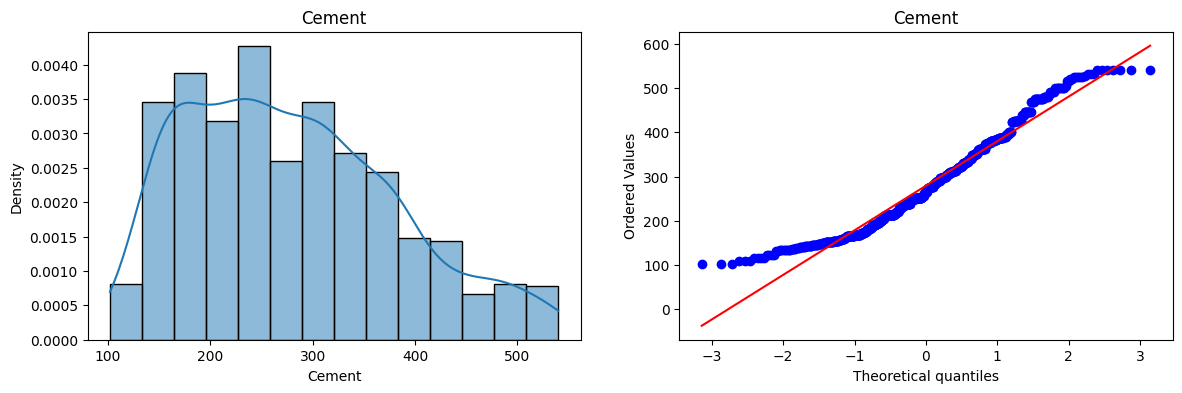

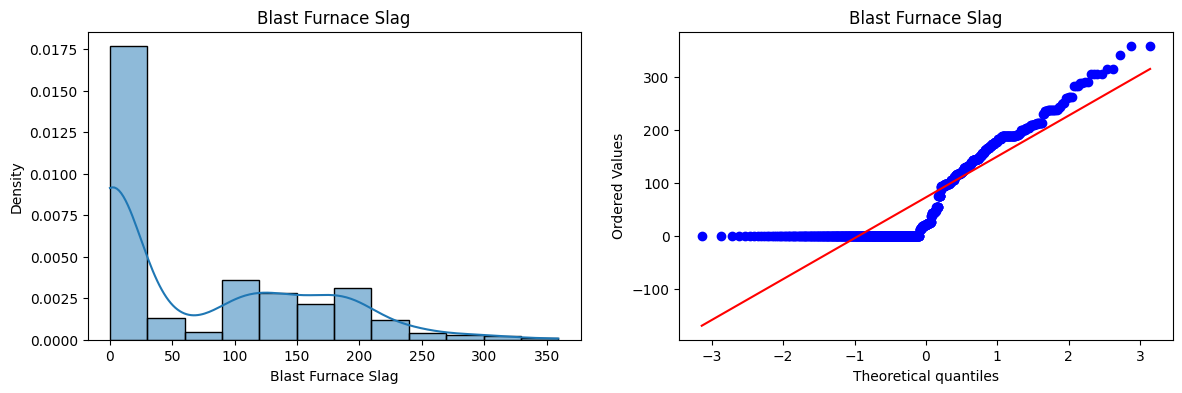

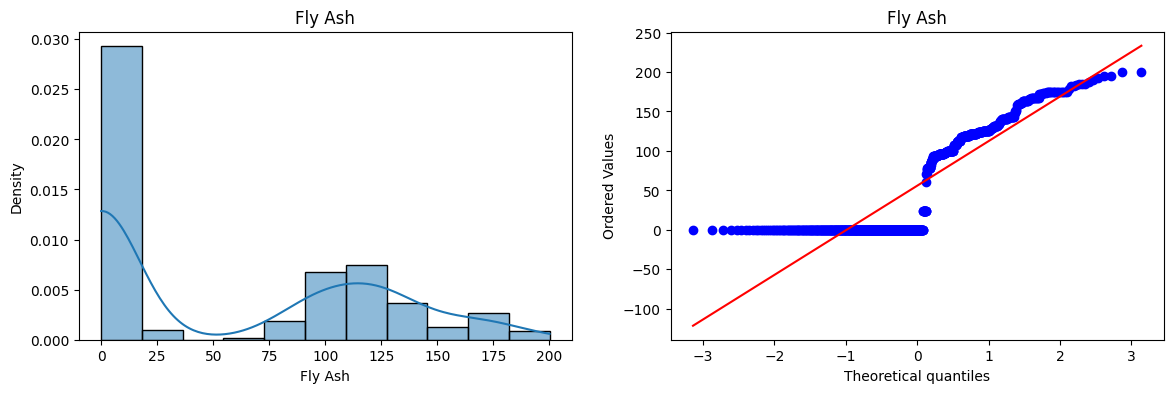

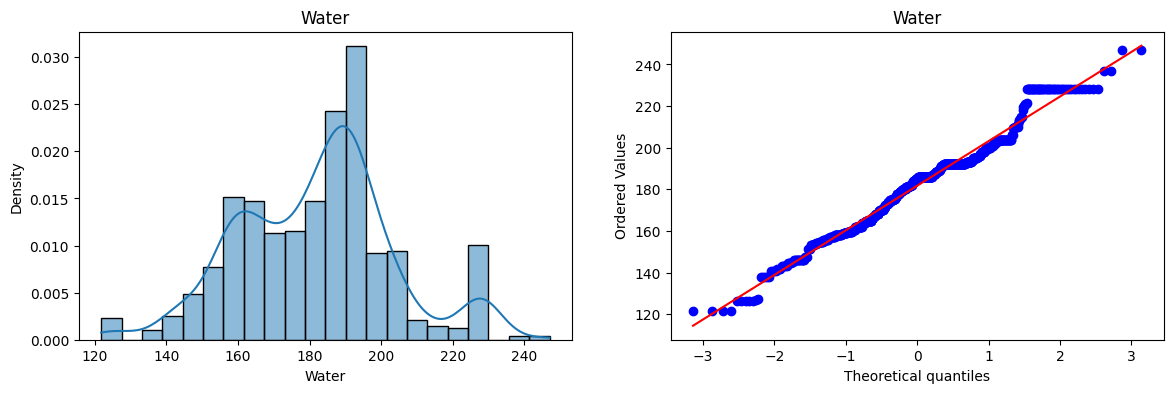

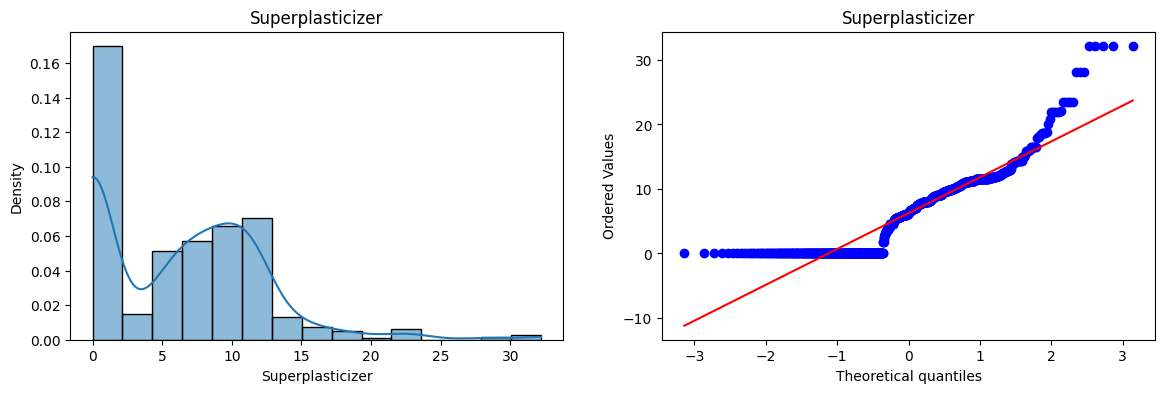

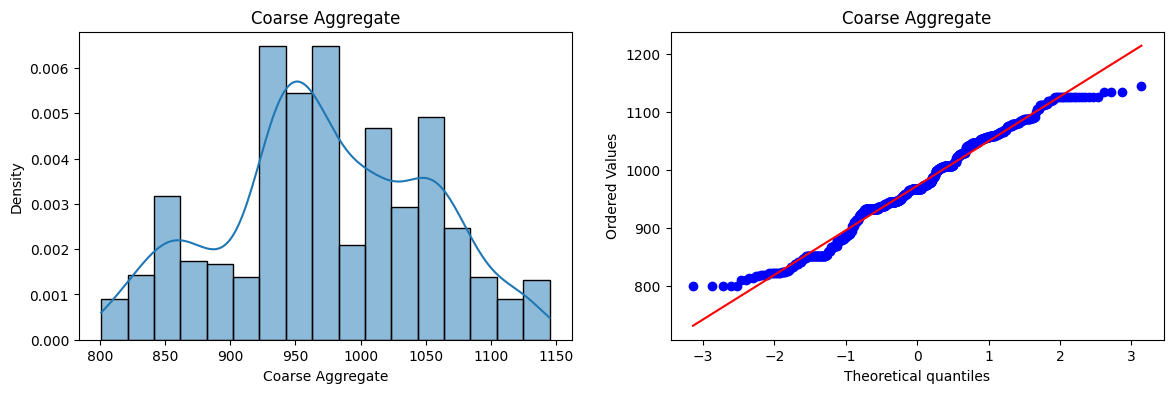

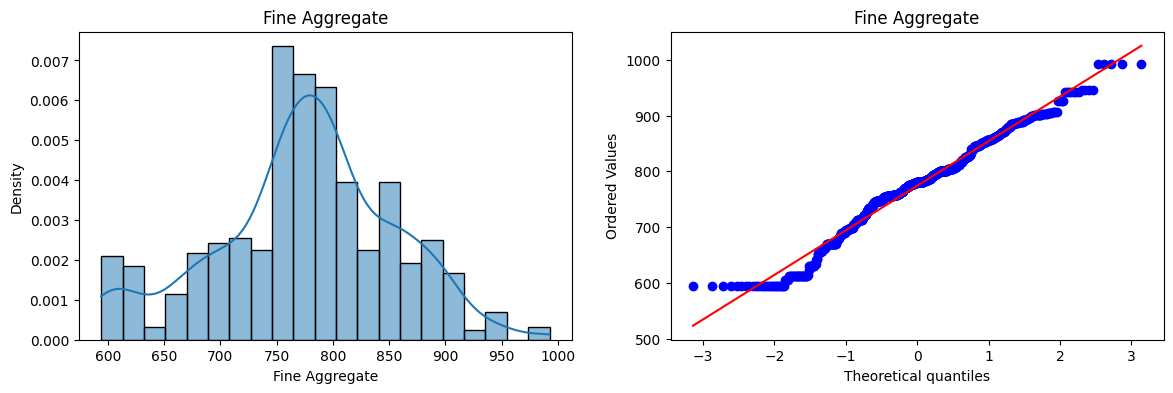

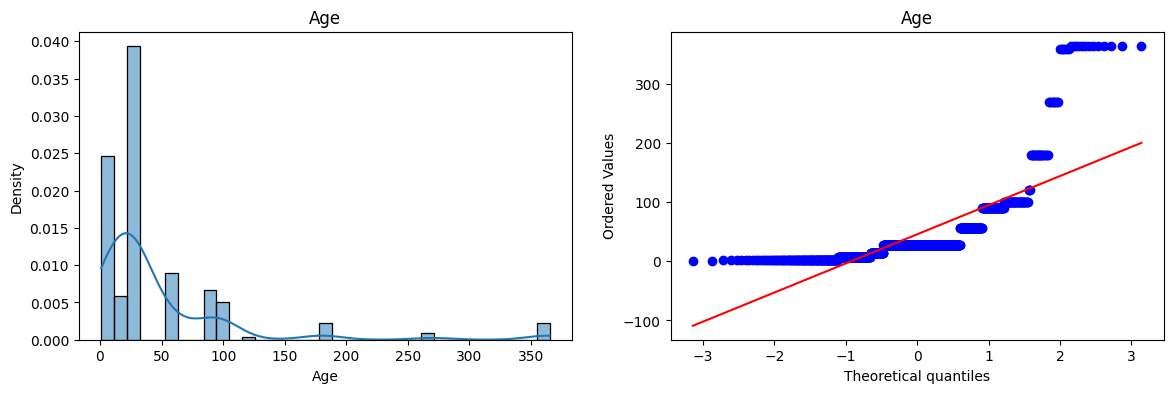

In [11]:
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col], kde= True, stat= "density")
    plt.title(col)
    
    plt.subplot(122)
    stats.probplot(x_train[col], plot= plt)
    plt.title(col)
    
    plt.show()

Clost to Norm-Dist : Cement, Water, Coarse agg, Fine agg

# Applying Box-Cox Tranform

In [12]:
pt = PowerTransformer(method='box-cox')

x_train_transformed = pt.fit_transform(x_train+0.0000000001)
x_test_transformed = pt.transform(x_test+0.0000000001)

In [13]:
# know your lambda

temp_df = pd.DataFrame({
    "Columns" : x_train.columns,
    "lambda" : pt.lambdas_
})
temp_df

,Columns,lambda
0,Cement,0.168477
1,Blast Furnace Slag,0.015077
2,Fly Ash,-0.014280
3,Water,0.748348
4,Superplasticizer,0.068741
5,Coarse Aggregate,1.299926
6,Fine Aggregate,1.772585
7,Age,0.046102


Applying regression after Box-Cox Transform

In [14]:
lr = LinearRegression()

lr.fit(x_train_transformed, y_train)

y_pred = lr.predict(x_test_transformed)

print("r2_score : ", r2_score(y_test,y_pred))

r2_score :  0.8113596977541546


In [15]:
# Cross validation score
pt = PowerTransformer(method='box-cox')
x_transformed = pt.fit_transform(x+0.0000000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

np.float64(0.6649320797568888)

In [16]:
x_train_transformed = pd.DataFrame(x_train_transformed, columns= x_train.columns)

Plotting after Box-Cox transformation & comparison

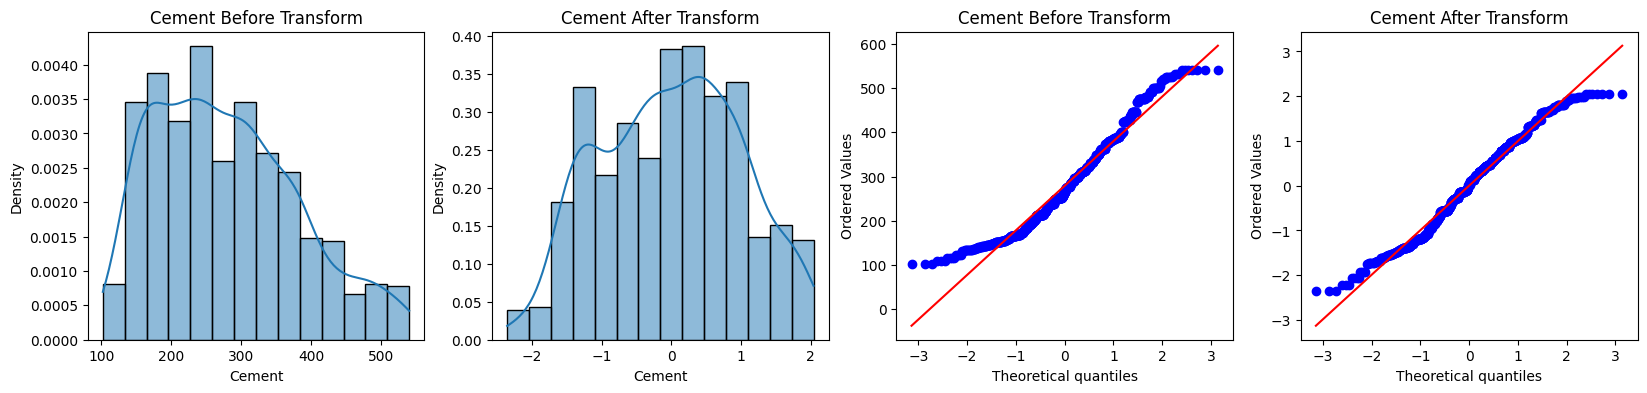

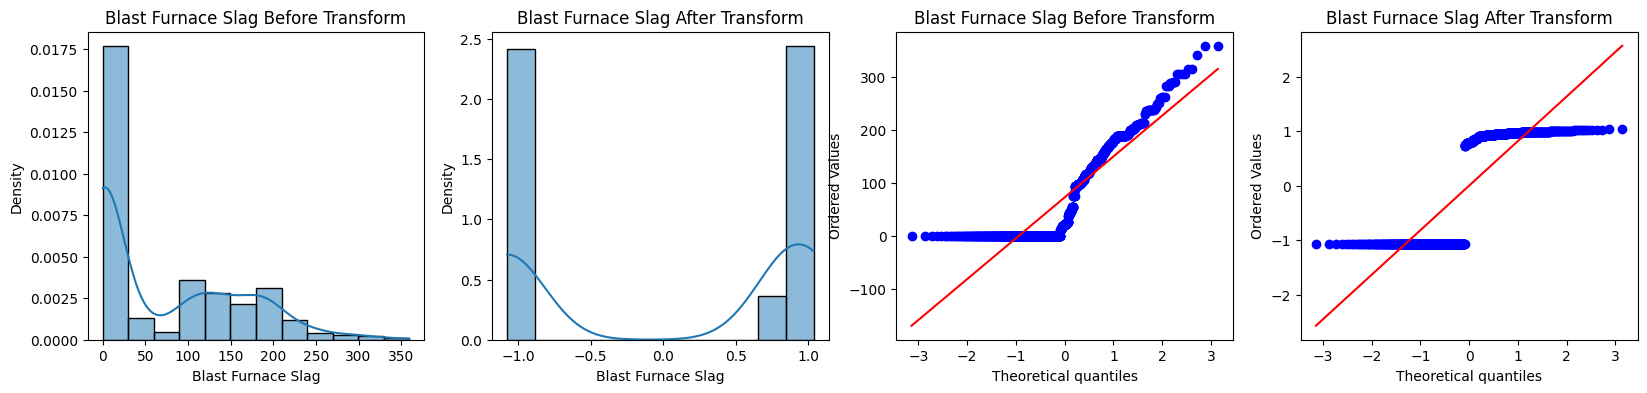

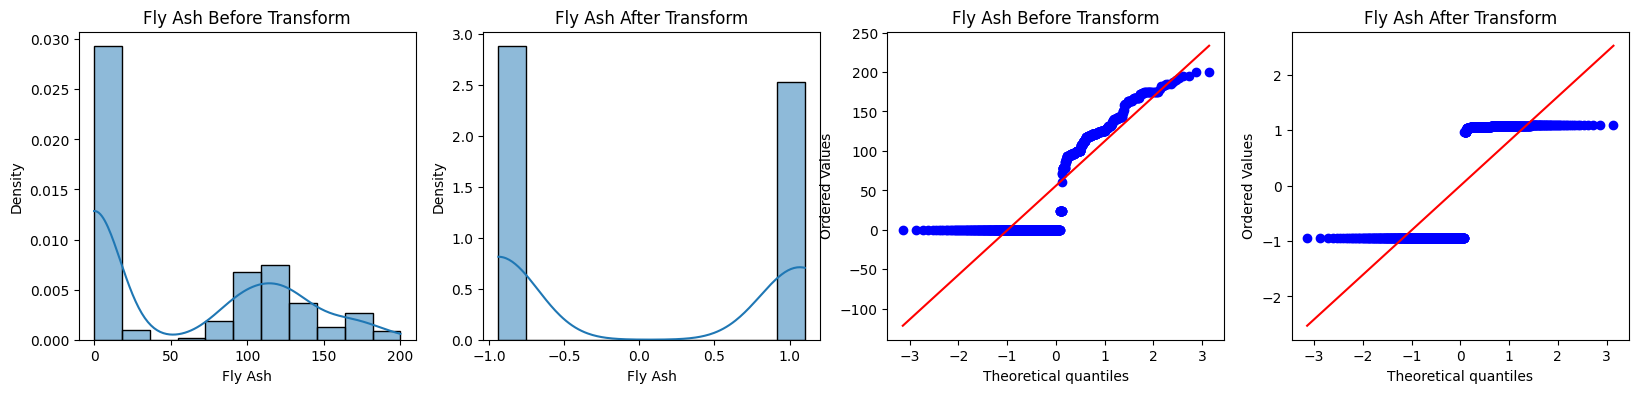

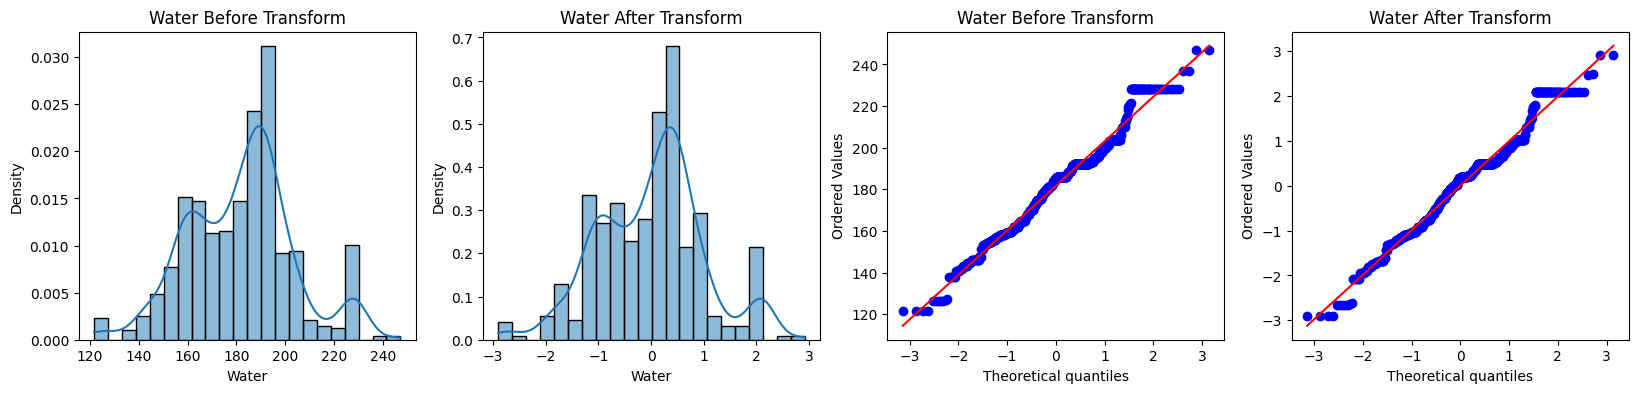

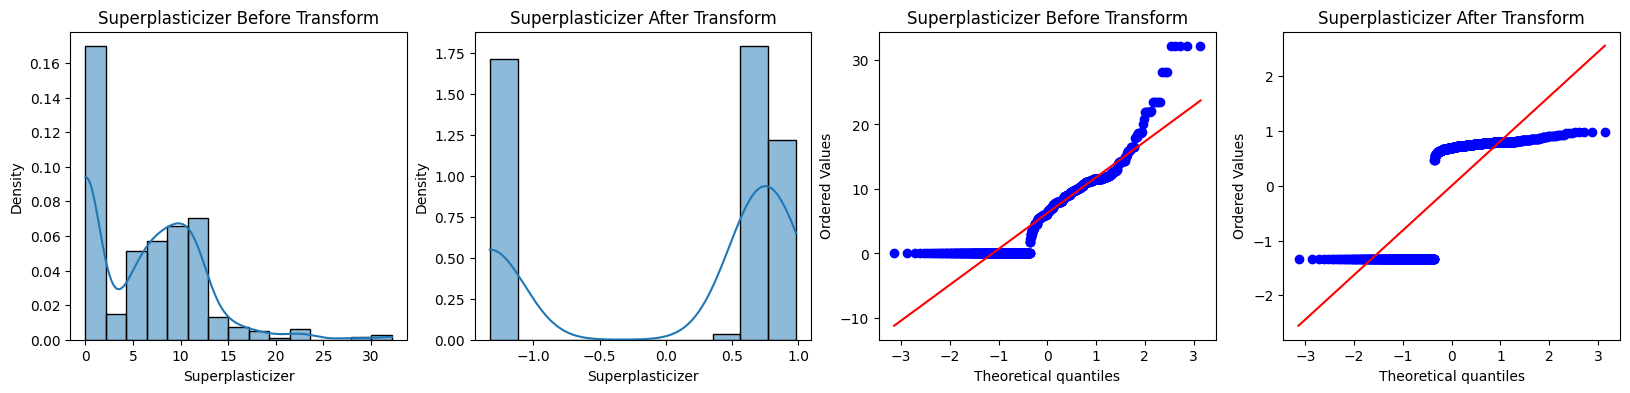

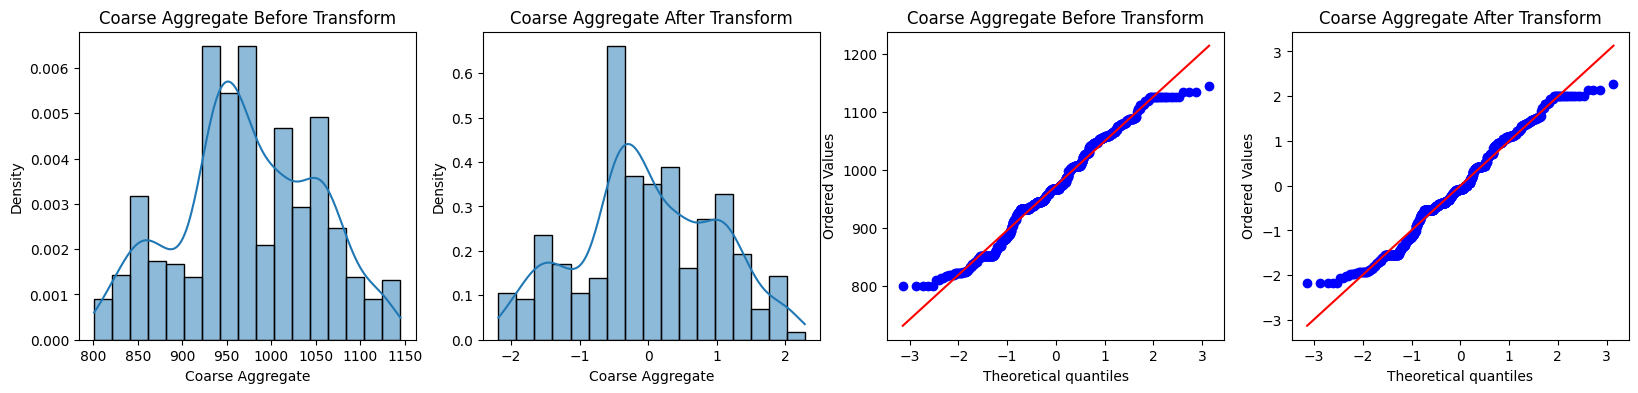

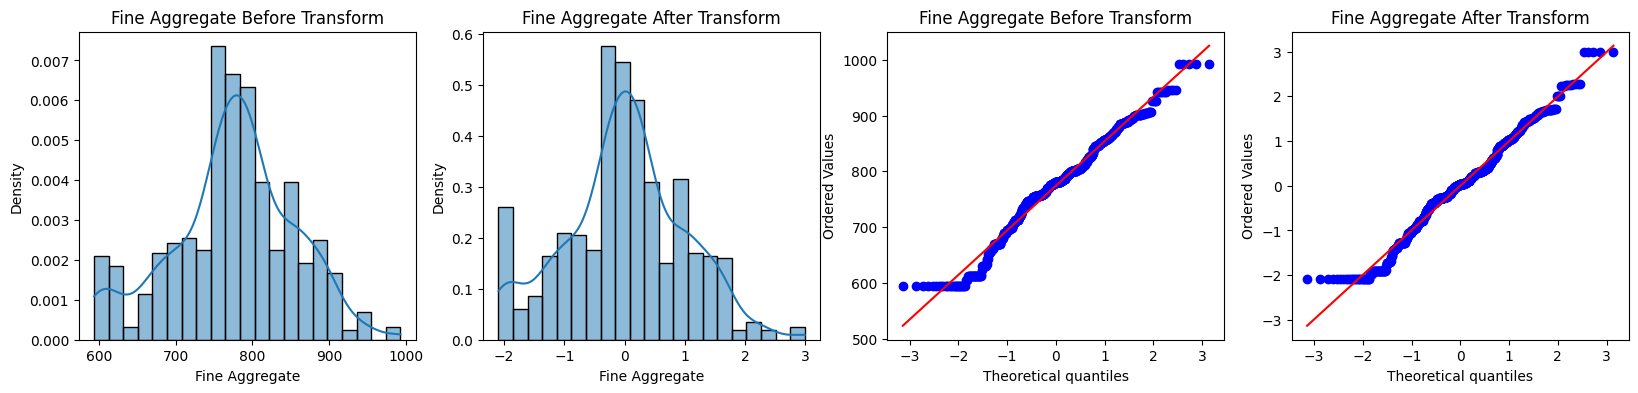

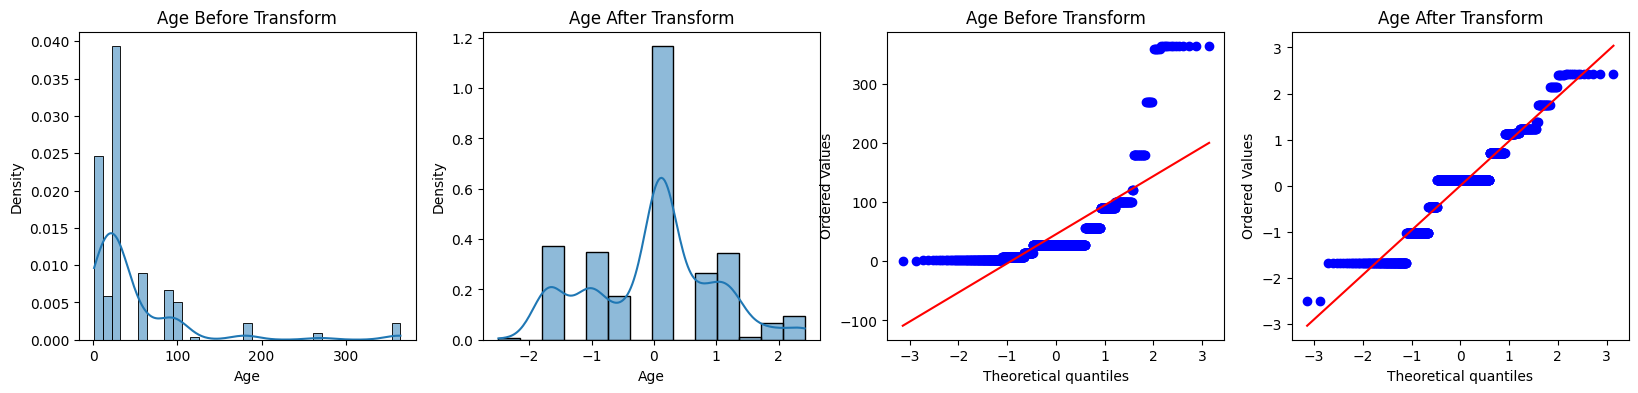

In [17]:
for col1, col2 in zip(x_train_transformed.columns, x_train.columns):
    
    plt.figure(figsize=(20,4))
    plt.subplot(141)
    sns.histplot(x_train[col2], kde= True, stat= "density")
    plt.title(f"{col2} Before Transform")

    plt.subplot(142)
    sns.histplot(x_train_transformed[col1], kde= True, stat= "density")
    plt.title(f"{col1} After Transform")
        
    plt.subplot(143)
    stats.probplot(x_train[col2], plot= plt)
    plt.title(f"{col2} Before Transform")
    
    plt.subplot(144)
    stats.probplot(x_train_transformed[col1], plot= plt)
    plt.title(f"{col1} After Transform")
    
    plt.show()

# Applying Yeo-Johnson Transform

In [18]:
pt1 = PowerTransformer()

x_train_transformed2 = pt1.fit_transform(x_train)
x_test_transformed2 = pt1.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_transformed2, y_train)

y_pred2 = lr.predict(x_test_transformed2)
print(f"r2_score : {r2_score(y_test,y_pred2)}")

temp_df2 = pd.DataFrame({
    "Columns" : x_train.columns,
    "Lambdas" : pt1.lambdas_
})

temp_df2

r2_score : 0.8143230268195292


,Columns,Lambdas
0,Cement,0.165657
1,Blast Furnace Slag,0.004657
2,Fly Ash,-0.096596
3,Water,0.746824
4,Superplasticizer,0.283352
5,Coarse Aggregate,1.300333
6,Fine Aggregate,1.773636
7,Age,-0.001590


In [19]:
# Cross validation score

pt = PowerTransformer()
x_train_transformed2 = pt.fit_transform(x)

lr = LinearRegression()
np.mean(cross_val_score(lr,x_train_transformed2,y,scoring='r2'))

np.float64(0.6834625126992443)

In [20]:
x_train_transformed2 = pd.DataFrame(x_train_transformed2, columns= x_train.columns)

Plotting after Yeo-Johnson Transform

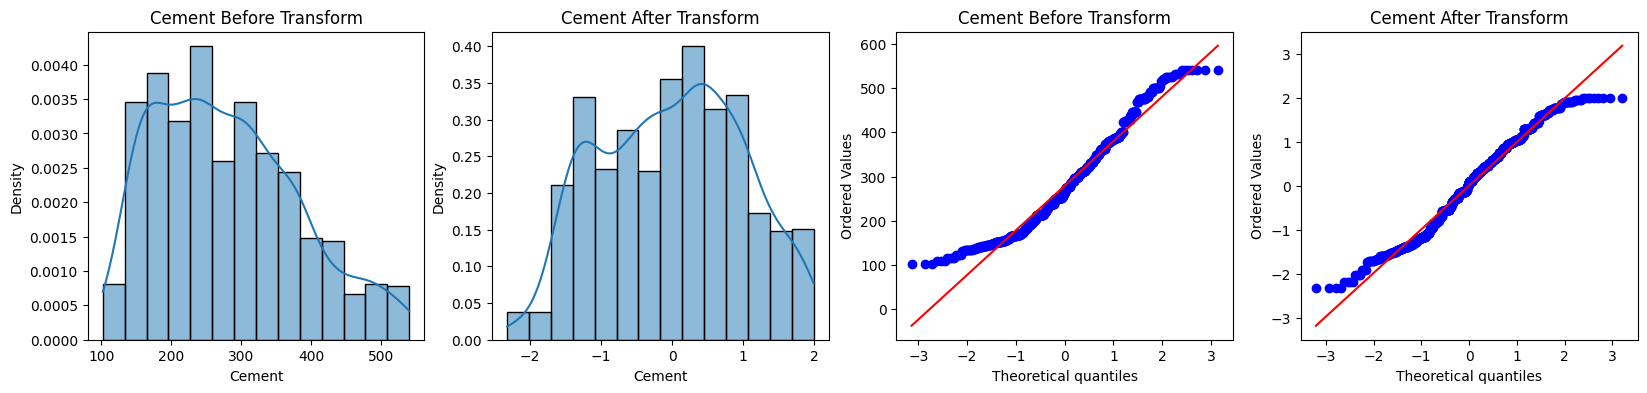

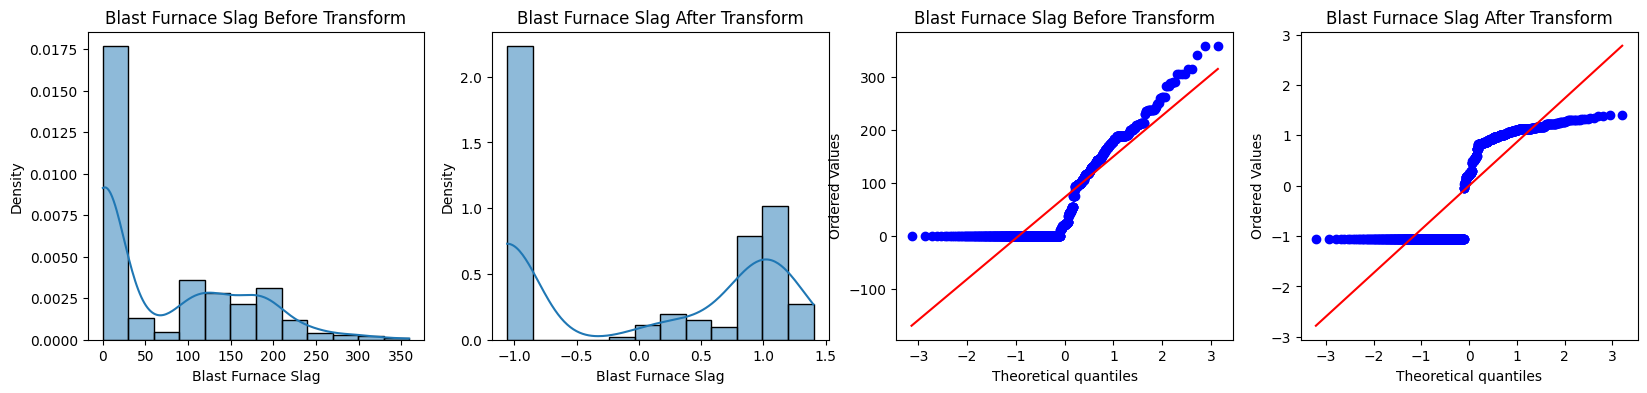

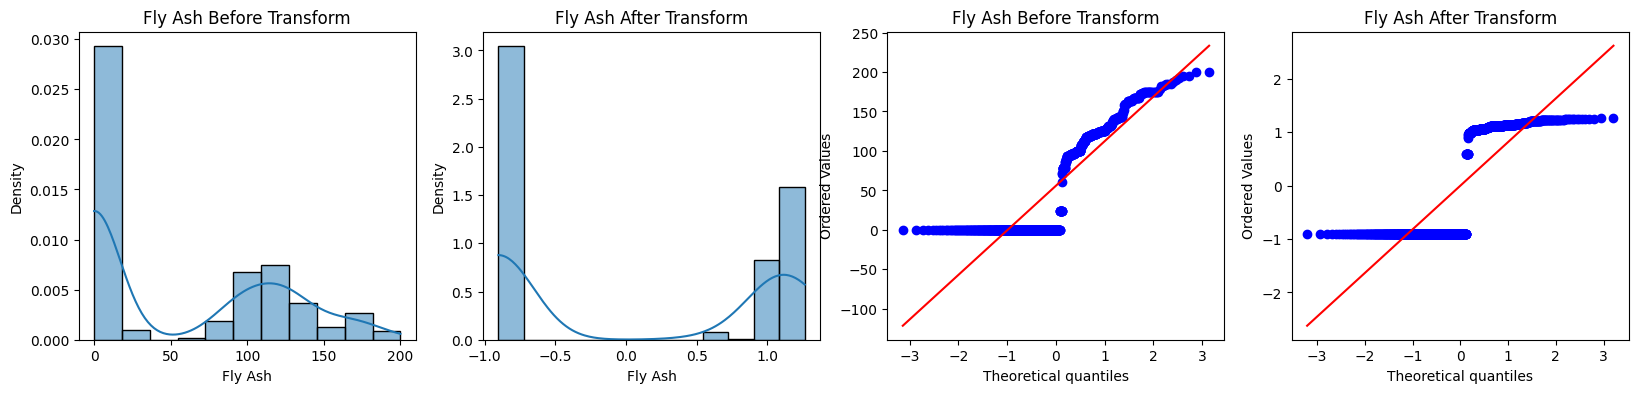

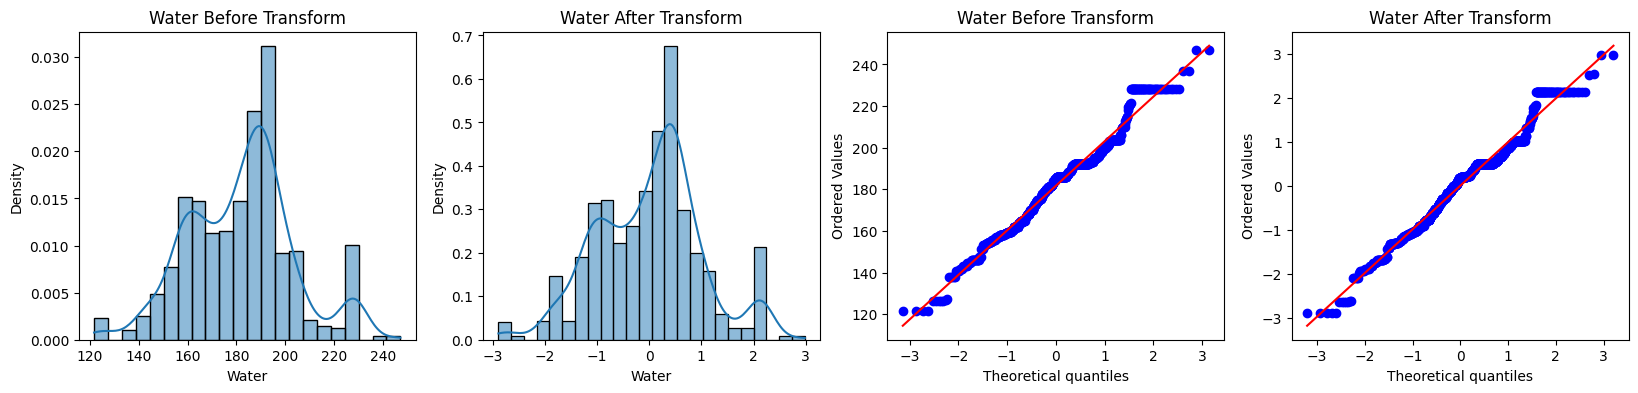

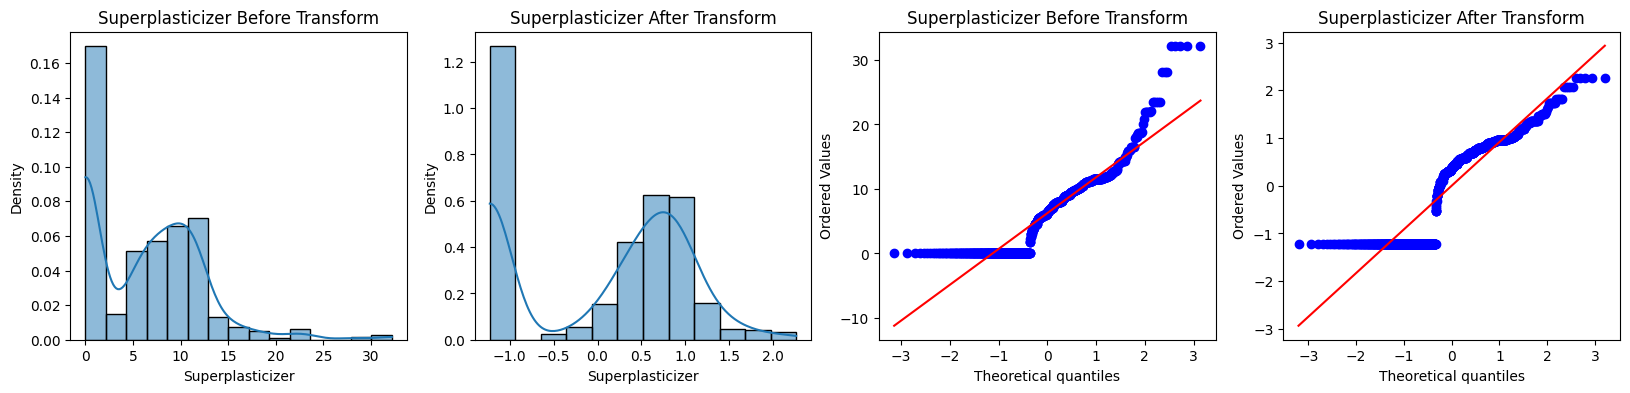

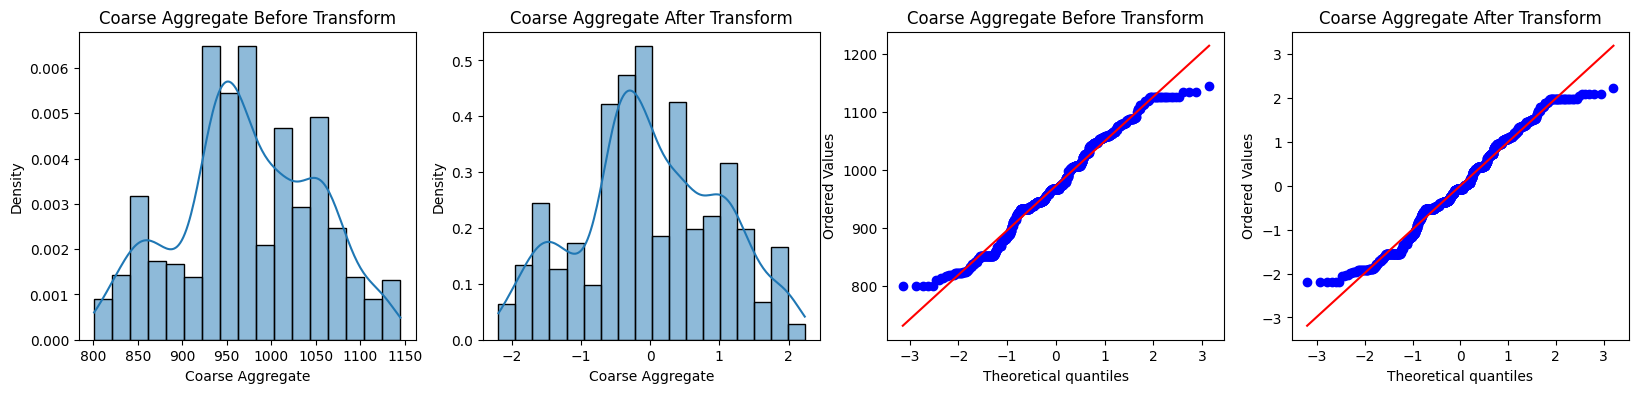

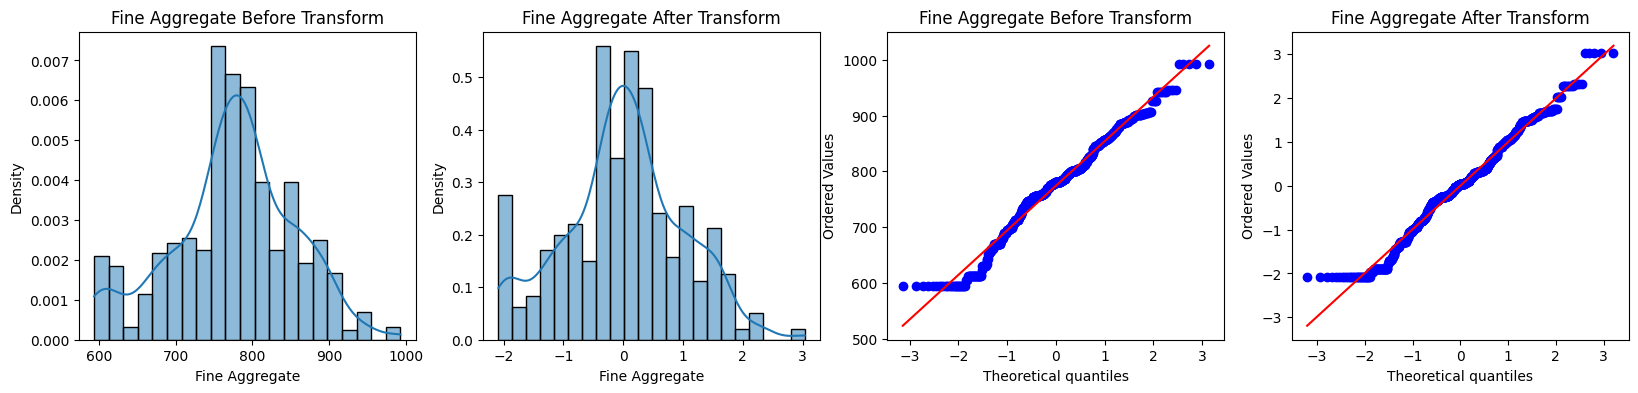

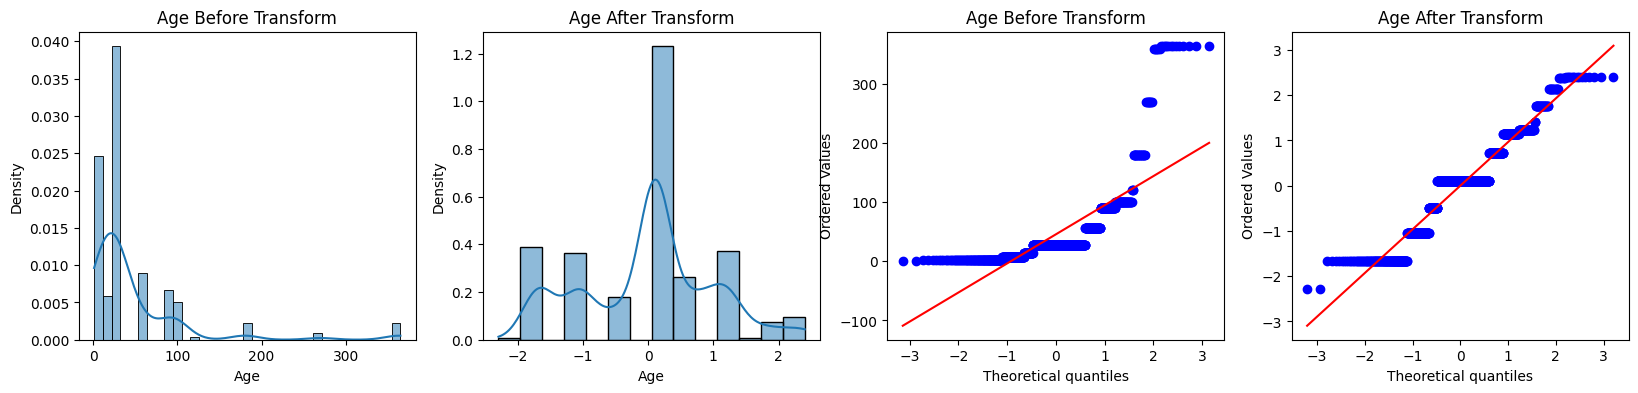

In [21]:
for col1, col2 in zip(x_train_transformed2.columns, x_train.columns):
    
    plt.figure(figsize=(20,4))
    plt.subplot(141)
    sns.histplot(x_train[col2], kde= True, stat= "density")
    plt.title(f"{col2} Before Transform")

    plt.subplot(142)
    sns.histplot(x_train_transformed2[col1], kde= True, stat= "density")
    plt.title(f"{col1} After Transform")
        
    plt.subplot(143)
    stats.probplot(x_train[col2], plot= plt)
    plt.title(f"{col2} Before Transform")
    
    plt.subplot(144)
    stats.probplot(x_train_transformed2[col1], plot= plt)
    plt.title(f"{col1} After Transform")
    
    plt.show()